## Importing libaries

In [2]:
import pandas as pd

from sklearn import preprocessing
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn import model_selection
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics, neighbors
import seaborn as sns
from matplotlib import pyplot as plt


## Reading the data

In [3]:
df = pd.read_csv('/content/dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36891 entries, 0 to 36890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   CATEGORY  36891 non-null  object
 1   CONTENT   36891 non-null  object
 2   SUMMARY   36891 non-null  object
dtypes: object(3)
memory usage: 864.8+ KB


In [9]:
df.head()

,CATEGORY,CONTENT,SUMMARY
0,0,The Federal Reserve approved Ally Financial In...,The Federal Reserve approved Ally Financial In...
1,0,— Major shareholders of Duke Energy Corp. have...,— Major shareholders of Duke Energy Corp. have...
2,0,Photos taken earlier this month show that Nort...,Photos taken earlier this month show that Nort...
3,0,Thanks to dogged reporting by the Associated P...,Thanks to dogged reporting by the Associated P...
4,0,The energy giant says it is committed to clean...,The energy giant says it is committed to clean...


In [4]:
# Encode labels in column 'category'.
label_encoder = preprocessing.LabelEncoder()
df['CATEGORY']= label_encoder.fit_transform(df['CATEGORY'])

In [5]:
# group df by category and count how many
df_count = df.groupby('CATEGORY').count()
df_count

,CONTENT,SUMMARY
CATEGORY,,
0,7558,7558
1,8582,8582
2,10505,10505
3,10246,10246


## Feature Extraction using Bag of words

In [11]:
training_set, test_set, training_labels, test_labels = train_test_split(df["CONTENT"], df["CATEGORY"], test_size=0.33, random_state=42)

In [12]:
#Bag of words
vectorizer = CountVectorizer(min_df =2, ngram_range=(2,2))
bow_train_features = vectorizer.fit_transform(training_set)
bow_test_features = vectorizer.transform(test_set)

#### Classification using Bag of words features

Logistic Regression using Bag of words

Accuracy:  93.03490759753593 

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      2533
           1       0.95      0.96      0.95      2828
           2       0.92      0.94      0.93      3394
           3       0.94      0.92      0.93      3420

    accuracy                           0.93     12175
   macro avg       0.93      0.93      0.93     12175
weighted avg       0.93      0.93      0.93     12175



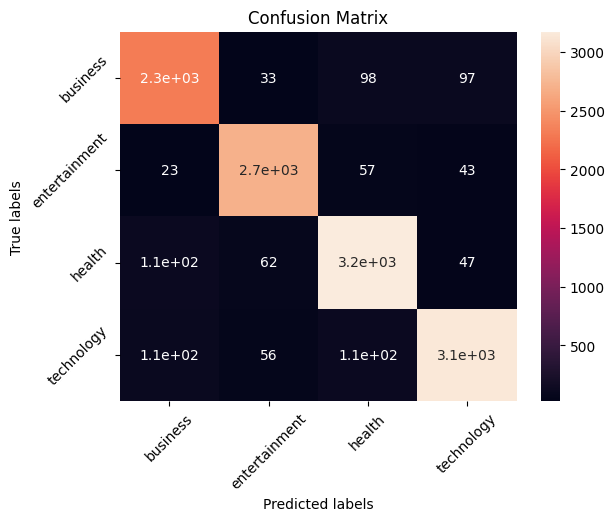

In [13]:
#Logistic Regression

logRegModel = LogisticRegression()
logRegModel.fit(bow_train_features,training_labels)

predictions_lr = logRegModel.predict(bow_test_features)

print("Logistic Regression using Bag of words\n")
print("Accuracy: ",accuracy_score(predictions_lr, test_labels)*100,"\n")

print("Classification Report\n")
print(classification_report(test_labels,predictions_lr))


#Plotting the confusion matrix
cm = confusion_matrix(test_labels, predictions_lr)
ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['business', 'entertainment','health','technology'],rotation =45);
ax.yaxis.set_ticklabels(['business', 'entertainment','health','technology'],rotation =45);
